## 1. Tensors
Tensors are a specialized data structure very similar to arrays and matrices. In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model's parameters.

Tensors are similar to NumPy's ndarrays, except that tensors can run on GPUs or other hardware accelerators.

### Initializing a Tensor

In [ ]:
import torch

# Create a tensor directly from data
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
print("x:", x)

# Create a tensor of zeros
y = torch.zeros(2, 2)
print("y:", y)

# Create a tensor of ones
z = torch.ones(2, 2)
print("z:", z)

# Create a random tensor
w = torch.rand(2, 2)
print("w:", w)

x: tensor([[1., 2.],
        [3., 4.]])
y: tensor([[0., 0.],
        [0., 0.]])
z: tensor([[1., 1.],
        [1., 1.]])
w: tensor([[0.2058, 0.1430],
        [0.3088, 0.4373]])


In [ ]:
import numpy as np
import math
# Create a tensor from a NumPy array
x = np.array([1,2,3])
x_np = torch.from_numpy(x)
print("x_np:", x_np)

x_np_2 = torch.tensor(x)
print("x_np_2:", x_np_2)

x_np: tensor([1, 2, 3])
x_np_2: tensor([1, 2, 3])


**Seems the same?**

In [ ]:
x[0] = 99

print("x_np:", x_np) # Memory sharing, efficient
print("x_np_2:", x_np_2) # Memory copy, safe

x_np: tensor([99,  2,  3])
x_np_2: tensor([1, 2, 3])


In [ ]:
help(torch.from_numpy)

Help on built-in function from_numpy in module torch:

from_numpy(...)
    from_numpy(ndarray) -> Tensor

    Creates a :class:`Tensor` from a :class:`numpy.ndarray`.

    The returned tensor and :attr:`ndarray` share the same memory. Modifications to
    the tensor will be reflected in the :attr:`ndarray` and vice versa. The returned
    tensor is not resizable.

    It currently accepts :attr:`ndarray` with dtypes of ``numpy.float64``,
    ``numpy.float32``, ``numpy.float16``, ``numpy.complex64``, ``numpy.complex128``,
    ``numpy.int64``, ``numpy.int32``, ``numpy.int16``, ``numpy.int8``, ``numpy.uint8``,
    and ``bool``.

    .. warning::
        Writing to a tensor created from a read-only NumPy array is not supported and will result in undefined behavior.

    Example::

        >>> a = numpy.array([1, 2, 3])
        >>> t = torch.from_numpy(a)
        >>> t
        tensor([ 1,  2,  3])
        >>> t[0] = -1
        >>> a
        array([-1,  2,  3])



### Attributes of a tensor
+ shape: The shape of the tensor
+ dtype: Data type. For integers, there are int32, int64, int8, uint8; for float, there are float32, float16, bfloat16, float64, etc.
+ device: which device the tensor is on

In [ ]:
tensor = torch.tensor([[1, 2, 3], [3, 4, 5]])

print(f"Shape of tensor: {tensor.shape}") # tensor.size()
print(f"Datatype of tensor: {tensor.dtype}") # torch.float16
print(f"Device tensor is stored on: {tensor.device}") # gpu (cuda)

Shape of tensor: torch.Size([2, 3])
Datatype of tensor: torch.int64
Device tensor is stored on: cpu


### Operations on Tensors

In [ ]:
# Move the tensor to GPU if available
if torch.cuda.is_available():
  tensor = tensor.to("cuda")
  print(f"device: ", tensor.device)

# convert dtype
tensor = tensor.to(torch.float64)
print("dtype: ", tensor.dtype)

# Standard numpy-like indexing and slicing
tensor = torch.tensor([[1,2,3], [3,4,5]])
print("First row: ", tensor[0])
print("First column: ", tensor[:,0])
print("Boolean indexing: ", tensor[tensor>2])

device:  cuda:0
dtype:  torch.float64
First row:  tensor([1, 2, 3])
First column:  tensor([1, 3])
Boolean indexing:  tensor([3, 3, 4, 5])


### Matrix multiplication

In [ ]:
tensor = torch.ones(3, 3)
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)
print("y1: ", y1)
print("y2: ", y2)

y1:  tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]])
y2:  tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]])


### Elementwise Product

In [ ]:
z1 = tensor * tensor
z2 = tensor.mul(tensor)
print("z1: ", z1)
print("z2: ", z2)

z1:  tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
z2:  tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


### Reshaping

In [ ]:
# Reshape
x = torch.arange(4.)
print("x: ", x)

x_view = x.view(2, -1)
print("x_view: ", x_view)
x_reshaped = x.reshape(2, 2)
print("x_reshaped: ", x_reshaped)

x:  tensor([0., 1., 2., 3.])
x_view:  tensor([[0., 1.],
        [2., 3.]])
x_reshaped:  tensor([[0., 1.],
        [2., 3.]])


**Memory sharing: think twice when you copy a tensor**

In [ ]:
x[0] = 99
print("x_view: ", x_view)
print("x_reshaped: ", x_reshaped)

x_view:  tensor([[99.,  1.],
        [ 2.,  3.]])
x_reshaped:  tensor([[99.,  1.],
        [ 2.,  3.]])


**Preferred way to copy a tensor**

Useful link: https://stackoverflow.com/questions/55266154/pytorch-preferred-way-to-copy-a-tensor

In [ ]:
x = torch.arange(4.)
y = x.clone().detach()

x[0] = 99
print("x: ", x)
print("x_clone: ", y)

x:  tensor([99.,  1.,  2.,  3.])
x_clone:  tensor([0., 1., 2., 3.])


### Tensor Broadcasting

In [ ]:
x1 = torch.tensor([[1, 2, 3], [3, 4, 5]])
x2 = torch.tensor([2, 2, 2])
doubled = x1 * x2

print("x1 shape", x1.shape)
print("x2 shape", x2.shape)
print(doubled)

x1 shape torch.Size([2, 3])
x2 shape torch.Size([3])
tensor([[ 2,  4,  6],
        [ 6,  8, 10]])


## 2. Automatic Differentation



-   Instead of computing backpropagation manually, an autodiff system performs backprop in a completely mechanical way.
-   An autodiff system will convert the program into a sequence of primitive operations which have specified routines for computing derivatives.

### Distinction of the concepts

-  **Backpropagation**: the mathematical algorithm we use to compute the gradient.
-  **Automatic differentiation (AutoDiff)**: any software that implements backpropagation.
  -   Examples: Autograd, TensorFlow, PyTorch, Jax, etc.
  -  **Reverse Mode AD**: A method to get exact derivatives efficiently, by storing information as you go forward that you can reuse as you go backwards



* Autograd can automatically differentiate native Python and Numpy code.
* It can handle a large subset of Python's features, including loops, conditional statements (if/else), recursion and closures.
* It can also compute higher-order derivatives.
* It uses reverse-mode differentiation (a.k.a. backpropagation) so it can efficiently take gradients of scalar-valued functions with respect to array-valued arguments.

**Sigmoid example**:

$f(x) = \cfrac{1}{(1 + exp(-x))}$, $f'(x) = f(x)(1 - f(x))$

In [ ]:
import torch

# Define the sigmoid function
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

# Create a tensor with requires_grad=True to track computations
x = torch.tensor(1.0, requires_grad=True, dtype=torch.float64)

# Perform the forward pass
y = sigmoid(x)

# Perform the backward pass to compute gradients
y.backward()

# Access the computed gradient
print(f"The gradient of sigmoid at x = {x} using torch is: {x.grad}")

# Manually calculate the true gradient for comparison
print(f"True gradient = {sigmoid(x) * (1 - sigmoid(x))}")

The gradient of sigmoid at x = 1.0 using torch is: 0.19661193324148188
True gradient = 0.19661193324148185


## 3. Neural Networks
Great! We have already see how to compute gradients of the sigmoid function w.r.t. its input. Now let's consider a much more complex and general function, i.e. Neural Networks.

- Typical training procedure of NNs and SGD:
  1. Define the neural network.
  2. Iterate over a dataset of inputs.
  3. Process input through the network.
  4. Compute the loss.
  5. Propagate gradients back into the network’s parameters.
  6. Update the weights of the network: `weight = weight - learning_rate * gradient`
- Practically, neural networks can be constructed using the torch.nn package, based on the class nn.Module.

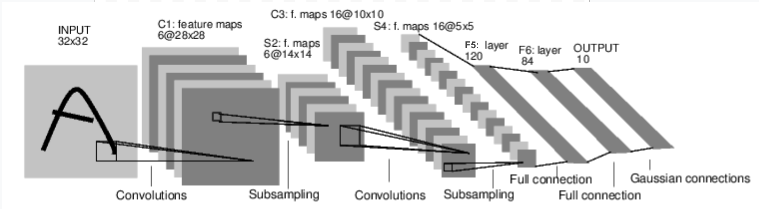

In [ ]:
# import necessary libraries
import torch
import torch.nn as nn # Layers (e.g., nn.Linear, nn.Conv2d) / loss functions (e.g., nn.CrossEntropyLoss)
import torch.nn.functional as F # Functional (stateless) implementations of layers and operations, such as F.relu, F.softmax

### 3.1 nn.Module
- Base class for all neural network modules.
- Any model we define **subclasses** this class.
- Can contain other **submodules** (eg. convolution), allowing them to be nested in a tree structure.

```python
## Example
class Model(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        # Define layers (with weights) in neural network
        # convolution
        # linear
        # ... ...

    def forward(self, x):
        # All stateless operations done in the neural network
        # return output of neural network
```

### 3.2 Convolution and Linear Layers
```python3
# Convolution:
# torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, ...)

# example:
self.conv1 = nn.Conv2d(1, 6, 5)
self.conv2 = nn.Conv2d(6, 16, 5)
```


<div>
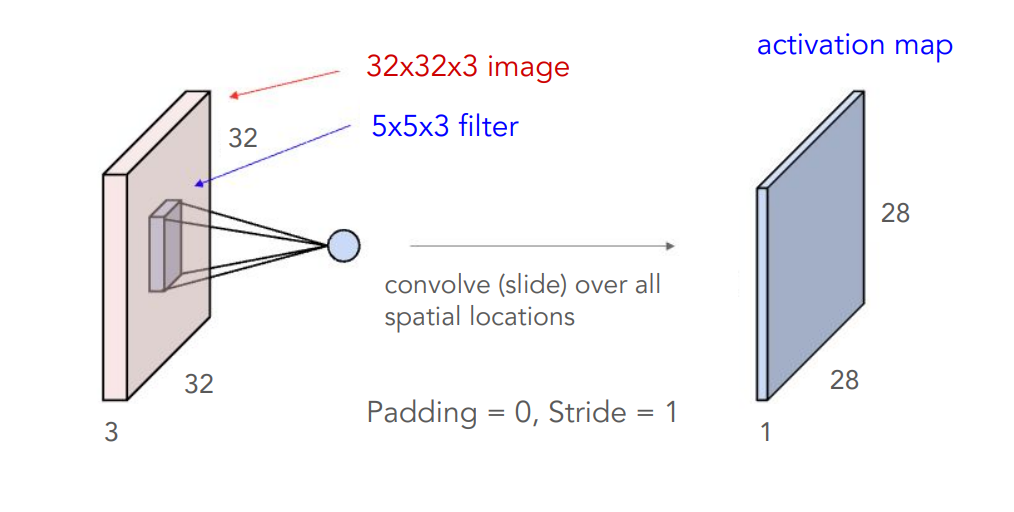
<div>

```python3
# Linear
# torch.nn.Linear(in_features, out_features, bias=True,...)

self.fc1 = nn.Linear(400, 120)
self.fc2 = nn.Linear(120, 84)
```

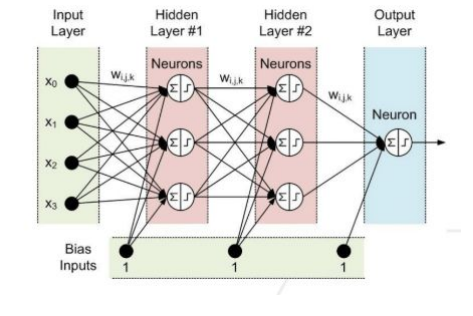

### 3.3 Maxpool and Relu
```python3
# maxpool
# torch.nn.functional.max_pool2d(input, kernel_size, stride=None, padding=0, ...) Note: stride defaults to kernel size

# relu
# torch.nn.functional.relu(input, inplace=False) → Tensor (for nonlinearity)

c1 = F.relu(self.conv1(input))
s2 = F.max_pool2d(c1, (2, 2)) # Only defined the kernel size
c3 = F.relu(self.conv2(s2))
```

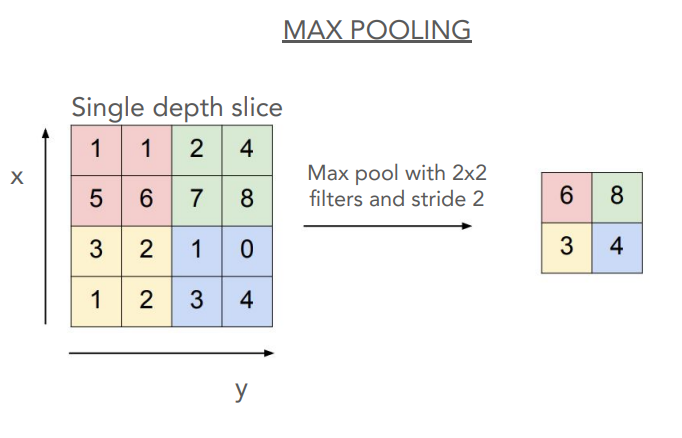

<div>
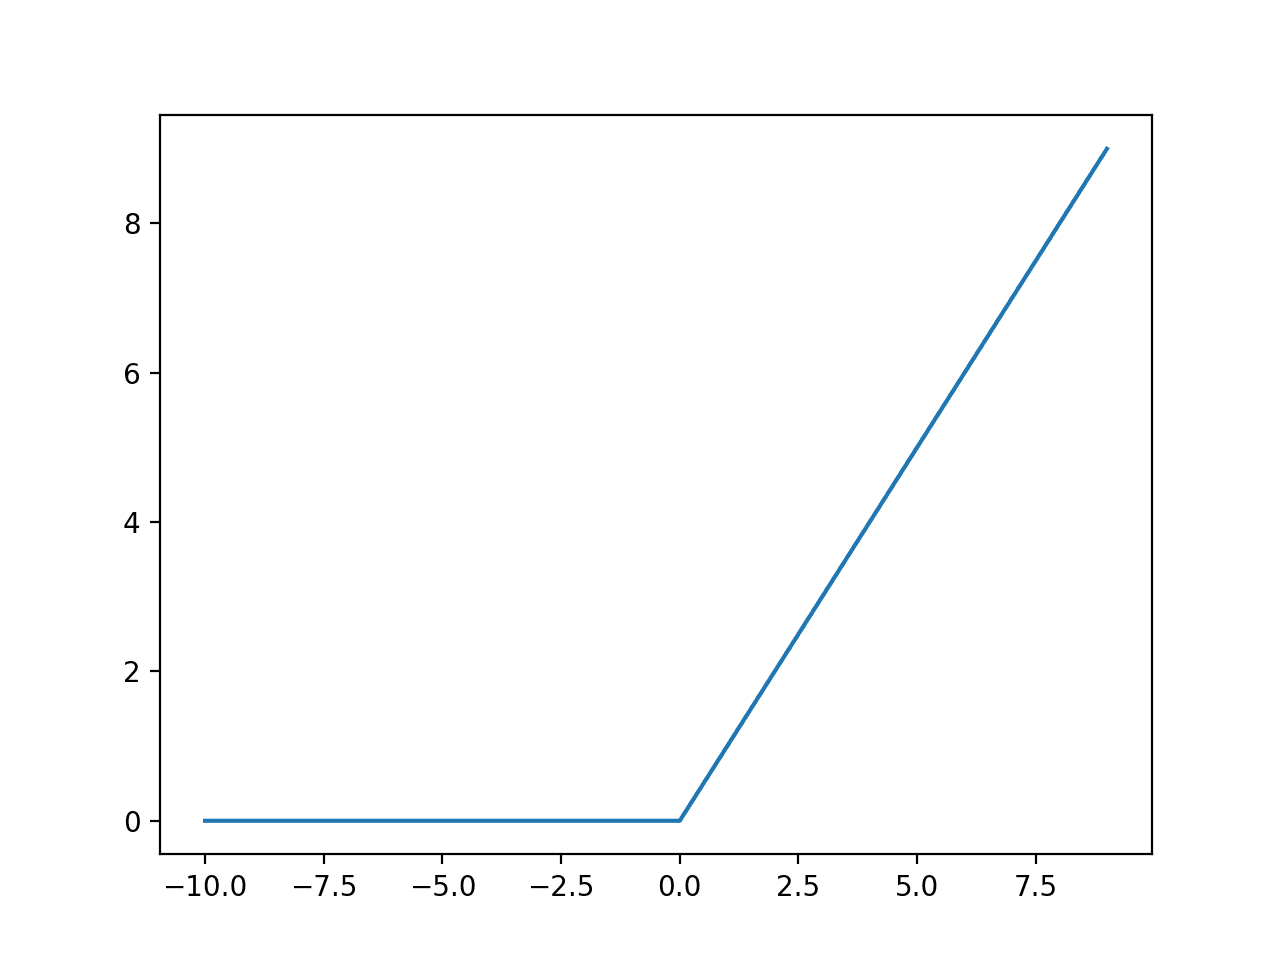
<div>

### 3.4 Putting the Pieces Together
- We only need to initialize the layers with weights (stateful).
- The forward function puts together the full pipeline of what the input goes through.
- The backward function (where gradients are computed) is automatically defined using autograd.

In [ ]:
class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        c1 = F.relu(self.conv1(input))
        s2 = F.max_pool2d(c1, (2, 2))
        c3 = F.relu(self.conv2(s2))
        s4 = F.max_pool2d(c3, 2)
        s4 = torch.flatten(s4, 1)
        f5 = F.relu(self.fc1(s4))
        f6 = F.relu(self.fc2(f5))
        output = self.fc3(f6)
        return output


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


- The learnable parameters of a model are returned by `net.parameters()`

In [ ]:
params = list(net.parameters())
for p in params:
    print(p.shape)

torch.Size([6, 1, 5, 5])
torch.Size([6])
torch.Size([16, 6, 5, 5])
torch.Size([16])
torch.Size([120, 400])
torch.Size([120])
torch.Size([84, 120])
torch.Size([84])
torch.Size([10, 84])
torch.Size([10])


- Input and output example with suitable dimensions.

In [ ]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)

tensor([[ 0.0018, -0.1597,  0.0008,  0.0701,  0.0501,  0.0270,  0.1339, -0.0640,
         -0.1193, -0.1243]], grad_fn=<AddmmBackward0>)


- torch.nn only supports mini-batches.
- Hence, for single samples, use `input.unsqueeze(0)` to add a fake batch dimension.

### 3.5 Loss Function and Back Propagation
- A loss function takes an (output, target) pair, and computes a value that estimates how far away the output is from the target.
- torch.nn provides several loss functions (MSE, cross entropy, KL divergence ...)

In [ ]:
output = net(input)
target = torch.randn(10)  # a dummy target, random numbers from a normal distribution with mean 0 and variance 1
print(target)
target = target.view(1, -1)  # make it the same shape as output
print(target)
criterion = nn.MSELoss()

loss = criterion(output, target)
print(loss)

tensor([-1.7853,  1.0478, -0.6583, -0.4619, -1.5947, -0.5052, -1.2163, -1.0625,
         0.1084, -1.6956])
tensor([[-1.7853,  1.0478, -0.6583, -0.4619, -1.5947, -0.5052, -1.2163, -1.0625,
          0.1084, -1.6956]])
tensor(1.3698, grad_fn=<MseLossBackward0>)


- Graph of computations: `input -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d -> flatten -> linear -> relu -> linear -> relu -> linear -> MSELoss -> loss`
- When we call loss.backward(), the whole graph is differentiated w.r.t. the neural net parameters.
- All Tensors in the graph that have requires_grad=True will have their .grad Tensor accumulated with the gradient.

In [ ]:
net.zero_grad()     # zeroes the gradient buffers of all parameters

print('conv1.bias.grad before backward: ', net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward: ', net.conv1.bias.grad)

conv1.bias.grad before backward:  None
conv1.bias.grad after backward:  tensor([ 0.0201,  0.0012,  0.0170,  0.0323, -0.0033,  0.0119])


### 3.6 Updating Weights
- Update the weights of the network: `weight = weight - learning_rate * gradient`

In [ ]:
# Very simple update example

learning_rate = 0.01
for f in net.parameters():
    f.data.sub_(f.grad.data * learning_rate)

- Practically, we don't manually perform gradient descent.
- Instead, use torch.optim optimizers that do what we just did more sophisticatedly.

In [ ]:
import torch.optim as optim

# create your optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01)

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update

## 4. Pytorch Dataset and Dataloaders

Datasets and DataLoaders are essential components for handling data in PyTorch.

A dataset is a cluster of data in a organized way. It stores data samples and expected values.

A dataloader is a tool that iterates through the dataset, grouping data into batches and enabling multiprocessing. It efficiently loads data in batches during training, improving performance and scalability.

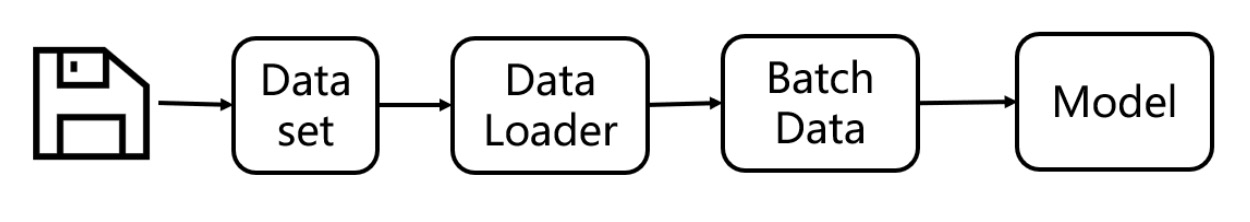

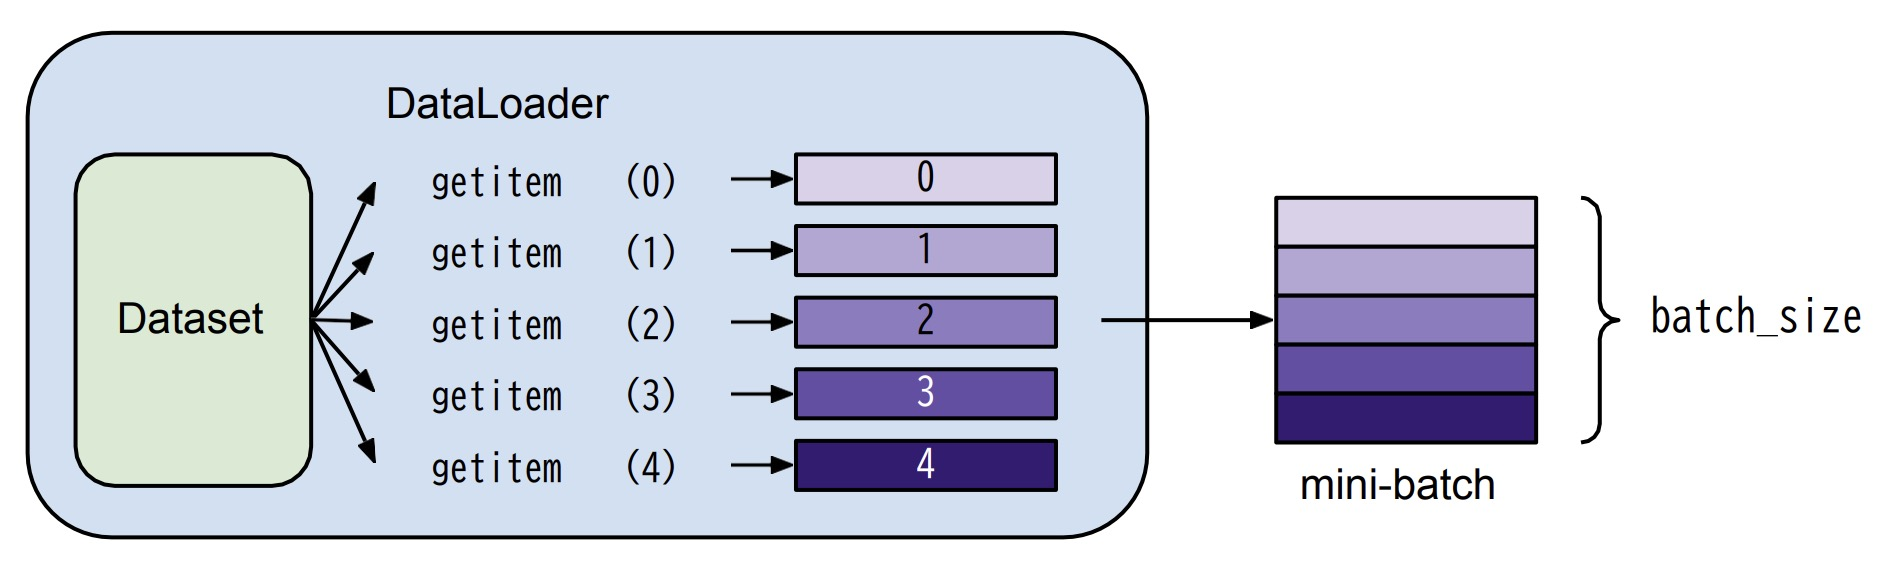

### 4.1. Simple Example

Let a dataset be the English alphabets "abcdefghijklmnopqrstuvwxyz"

In [ ]:
dataset = "abcdefghijklmnopqrstuvwxyz"

A simple dataloader could be implemented with the python code "for"

In [ ]:
for datapoint in dataset:
  print(datapoint)

a
b
c
d
e
f
g
h
i
j
k
l
m
n
o
p
q
r
s
t
u
v
w
x
y
z


When using the dataloader, we often like to shuffle the data. This is where torch.utils.data.DataLoader comes in handy. If each data is an index (0,1,2...) from the view of torch.utils.data.DataLoader, shuffling can simply be done by shuffling an index array.

torch.utils.data.DataLoader will need two imformation to fulfill its role. First, it needs to know the length of the data. Second, once torch.utils.data.DataLoader outputs the index of the shuffling results, the dataset needs to return the corresponding data.

Therefore, torch.utils.data.Dataset provides the imformation by two functions, `__len__()` and `__getitem__()` to support torch.utils.data.Dataloader

In [ ]:
import torch
import torch.utils.data
class ExampleDataset(torch.utils.data.Dataset):
  def __init__(self):
    # Read data & preprocess
    self.data = "abcdefghijklmnopqrstuvwxyz"

  def __getitem__(self,idx):
    # Returns one sample at a time
    # If the index is idx, what will be the data?
    return self.data[idx]

  def __len__(self):
    # Returns the size of the dataset
    # What is the length of the dataset
    return len(self.data)

dataset1 = ExampleDataset() # create the dataset
dataloader = torch.utils.data.DataLoader(dataset = dataset1,shuffle = True,batch_size = 1)
for datapoint in dataloader:
  print(datapoint)

['s']
['v']
['u']
['c']
['g']
['t']
['j']
['w']
['i']
['x']
['n']
['o']
['k']
['m']
['h']
['z']
['d']
['f']
['e']
['q']
['a']
['b']
['l']
['p']
['y']
['r']


A simple data augmentation technique can be done by changing the code in `__len__()` and `__getitem__()`. Suppose we want to double the length of the dataset by adding in the uppercase letters, using only the lowercase dataset, you can change the dataset to the following.

In [ ]:
import torch.utils.data
class ExampleDataset(torch.utils.data.Dataset):
  def __init__(self):
    self.data = "abcdefghijklmnopqrstuvwxyz"

  def __getitem__(self,idx): # if the index is idx, what will be the data?
    if idx >= len(self.data): # if the index >= 26, return upper case letter
      return self.data[idx%26].upper()
    else: # if the index < 26, return lower case, return lower case letter
      return self.data[idx]

  def __len__(self): # What is the length of the dataset
    return 2 * len(self.data) # The length is now twice as large

dataset1 = ExampleDataset() # create the dataset
dataloader = torch.utils.data.DataLoader(dataset = dataset1,shuffle = True,batch_size = 1)
for datapoint in dataloader:
  print(datapoint)

['B']
['q']
['k']
['z']
['C']
['X']
['K']
['j']
['u']
['h']
['Y']
['N']
['E']
['p']
['d']
['R']
['G']
['A']
['D']
['Q']
['J']
['l']
['Z']
['w']
['s']
['a']
['n']
['b']
['v']
['t']
['I']
['T']
['e']
['c']
['g']
['W']
['H']
['f']
['U']
['S']
['L']
['x']
['F']
['O']
['r']
['V']
['i']
['P']
['y']
['o']
['M']
['m']


### 4.2. Real Dataset

Now we'll use the FashionMNIST dataset, which contains 60,000 training images and 10,000 testing images of 10 different clothing items.

In [ ]:
import torchvision
import torchvision.transforms as transforms

# Define data transformations
transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the FashionMNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# Create DataLoaders for train and test datasets
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=512, shuffle=True, num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=512, shuffle=False, num_workers=2
)

print("Num training examples: {}".format(len(train_dataset)))
print("Num test examples: {}".format(len(test_dataset)))


# List of class labels
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.5MB/s]

Num training examples: 60000
Num test examples: 10000


### 4.3. Visualizing Examples from the FashionMNIST Dataset

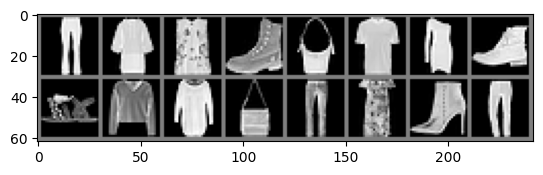

Trouser -- Pullover -- Shirt -- Ankle boot -- Bag -- T-shirt/top -- Dress -- Ankle boot
Sandal -- Pullover -- Pullover -- Bag -- Trouser -- Dress -- Ankle boot -- Trouser


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display the images in a grid along with their labels
imshow(torchvision.utils.make_grid(images[:16]))
print(" -- ".join(f"{classes[labels[j]]}" for j in range(8)))
print(" -- ".join(f"{classes[labels[j]]}" for j in range(8,16)))

With the dataset loaded and the DataLoader created, we can now train our neural network using the FashionMNIST dataset. Let's modify our previous SimpleNet example to handle 28x28 images and 10 output classes.

## 5. Build a training pipeline

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Define the neural network for FashionMNIST
class FashionMNISTNet(nn.Module):
    def __init__(self):
        super(FashionMNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# IMPORTANT CODE BELOW
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create an instance of the neural network
net = FashionMNISTNet()
print(net)

# Move the model to the GPU if available
net.to(device)

# Define the loss function and the optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

# Train the neural network using the FashionMNIST dataset
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader, 0):

        # Move the inputs and labels to the GPU if available
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = net(inputs)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Update the running loss
        running_loss += loss.item()

    # Print the average loss for this epoch
    avg_loss = running_loss / (i + 1)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")
print("Training finished.")

Using device: cuda
FashionMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)
Epoch [1/5], Loss: 1.7267
Epoch [2/5], Loss: 0.6675
Epoch [3/5], Loss: 0.5825
Epoch [4/5], Loss: 0.5181
Epoch [5/5], Loss: 0.4737
Training finished.


Now that we have trained our neural network, let's evaluate its performance on the test dataset.

In [ ]:
# Test the neural network
correct = 0
total = 0

# Set the model to evaluation mode
net.eval()

# Disable gradient calculation
with torch.no_grad():
    for inputs, labels in test_loader:

        # Move the inputs and labels to the GPU if available
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        pred = net(inputs)

        # Update the total number of samples and correct predictions
        total += labels.size(0)
        correct += (pred.argmax(1) == labels).sum().item()

# Calculate the accuracy
accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 82.16%


Not bad!

Let's inspect number of total parameters and training parameters in the model:

In [ ]:
total_params = sum(p.numel() for p in net.parameters())
print(f'{total_params:,} total parameters.')
total_trainable_params = sum(
    p.numel() for p in net.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} training parameters.')


116,234 total parameters.
116,234 training parameters.


Now that we have a trained model, if we want to adapt the model to another dataset with only 5 classes, we can freeze earlier layers and only train on the last fully-connected layer.

In [ ]:
# Freeze earlier layers
for param in net.parameters():
    param.requires_grad = False

n_inputs = net.fc3.in_features
n_classes = 5
net.fc3 = nn.Linear(n_inputs, n_classes)
total_params = sum(p.numel() for p in net.parameters())
print(f'{total_params:,} total parameters.')
total_trainable_params = sum(
    p.numel() for p in net.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} training parameters.')

115,909 total parameters.
325 training parameters.


## 6. Common errors


The following code blocks show some common errors while using the torch library. First, execute the code with error, and then execute the next code block to fix the error. We need to change the runtime to GPU.


In [ ]:
import torch

### 6.1. Different device error

In [ ]:
model = torch.nn.Linear(5,1).to("cuda:0")
x = torch.Tensor([1,2,3,4,5]).to("cpu")
y = model(x)

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

Fixed:

In [ ]:
x = torch.Tensor([1,2,3,4,5]).to("cuda:0")
y = model(x)
print(y.shape)

torch.Size([1])


### 6.2. Mismatched dimensions error


In [ ]:
x = torch.randn(4,5)
y= torch.randn(5,4)
z = x + y

RuntimeError: The size of tensor a (5) must match the size of tensor b (4) at non-singleton dimension 1

Fixed:

In [ ]:
y= y.transpose(0,1)
z = x + y
print(z.shape)

torch.Size([4, 5])


### 6.3 Cuda out of memory error

In [ ]:
import torch
import torchvision.models as models
resnet18 = models.resnet18().to("cuda:0") # Neural Networks for Image Recognition
data = torch.randn(2048,3,244,244) # Create fake data (2048 images)
out = resnet18(data.to("cuda:0")) # Use Data as Input and Feed to Model
print(out.shape)


OutOfMemoryError: CUDA out of memory. Tried to allocate 7.27 GiB. GPU 0 has a total capacity of 14.56 GiB of which 5.73 GiB is free. Including non-PyTorch memory, this process has 8.83 GiB memory in use. Of the allocated memory 8.69 GiB is allocated by PyTorch, and 3.52 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Fixed:

In [ ]:
for d in data:
  out = resnet18(d.to("cuda:0").unsqueeze(0))
print(out.shape)

torch.Size([1, 1000])


### 6.4. Mismatched tensor type

In [ ]:
import torch.nn as nn
L = nn.CrossEntropyLoss()
outs = torch.randn(5,5)
labels = torch.Tensor([1,2,3,4,0])
lossval = L(outs,labels) # Calculate CrossEntropyLoss between outs and labels

RuntimeError: expected scalar type Long but found Float

Fixed:

In [ ]:
labels = labels.long()
lossval = L(outs,labels)
print(lossval)

tensor(2.1297)
